Дискретное преобразование Фурье и быстрое преобразование Фурье

n = 1024

1. Единичный импульс
$$ 
F = \begin{cases}
F(0) = 1 \\
F(n) = 0
\end{cases}
$$

2. Константа
$$
F(n) = A, A - const
$$

3. Сумма синусов
$$
F = \sin(2\pi f_1) + sin(2\pi f_2)
$$

4. Синус с белым шумом
$$
F = \sin(2\pi f) + \text{rand}(n)
$$

5. Гауссово распределение
$$
F = \frac1{\sqrt{2\pi}} \int_{-\infty}^{\infty} e ^{-\frac{x^2}2} dx
$$


In [67]:
import matplotlib.pyplot as plt
import numpy as np

In [68]:
N = 1024

t_min = -1
t_max = 1

t = np.linspace(t_min, t_max, N)

In [69]:
def FImpulse(t):
    if abs(t) <= 1e-6:
        return 1
    else:
        return 0

In [70]:
def sumSinSignal(t, f_1=2, f_2=3):
    return np.sin(2 * np.pi * f_1 * t) + np.sin(2 * np.pi * f_2 * t)

In [71]:
def FConstSignal(t, A=1):
    return A

In [72]:
def FNoisedSin(t, f=2, noise_ampl=0.05):
    return np.sin(2 * np.pi * f * t) + np.random.normal(0, noise_ampl)

In [73]:
def FGausse(t, A=1, sigma=0.4):
    return A * np.exp(-t**2 / (2 * sigma**2))

In [74]:
def DFT(data):
    N = len(data)
    w = np.exp(-2j * np.pi / N)
    X = np.zeros(N, dtype=complex)
    
    
    for k in range(N):
        for n in range(N):
            X[k] += data[n] * w**(k * n)
        
    return X

In [75]:
def IDFT(data):
    N = len(data)
    w = np.exp(2j * np.pi / N)
    X = np.zeros(N, dtype=complex)
    

    for n in range(N):
        for k in range(N):
            X[n] += data[k] * w**(k * n)
        X[n] /= N 
        
    return X

In [76]:
def FFT(data):
    N = len(data)
    
    # if N == 1: 
    #     return np.asarray(data, dtype=complex)
    if N < 32:
        return DFT(data)
    w = np.exp(-2j * np.pi / N)

    P_e, P_o = data[0::2], data[1::2]

    y_e, y_o = FFT(P_e), FFT(P_o)

    # X_even = FFT(data[::2]) # 0, 2, 4, ...
    # X_odd = FFT(data[1::2]) # 1, 3, 5, ...
    
    y = np.zeros(N, dtype=complex)
    
    for i in range(N//2):
        y[i] = y_e[i] + w**i * y_o[i]
        y[i + N//2] = y_e[i] - w**i * y_o[i]

    return y

In [77]:
def IFFT(data):
    N = len(data)
    
    if N == 1:  
        return np.asarray(data, dtype=complex)

    w = np.exp(2j * np.pi / N)

    P_e, P_o = data[0::2], data[1::2]

    y_e, y_o = IFFT(P_e), IFFT(P_o)
    
    y = np.zeros(N, dtype=complex)

    
    for i in range(N//2):
        y[i] = y_e[i] + w**i * y_o[i]
        y[i + N//2] = y_e[i] - w**i * y_o[i]

    return y / N

In [88]:
import matplotlib.gridspec as gridspec
import time

def AnalaizerSignal(signal_func, signal_name, N=1024, f_max=500):
    # N = 2048 # кол-во отсчётов

    t_min = -1
    t_max = 1
    t = np.linspace(t_min, t_max, N)

    w = np.fft.fftfreq(N, np.abs(t_max - t_min) / N)

    # Специальная обработка для импульса
    if signal_func.__name__ == 'FImpulse':
        signal = np.zeros(N)
        signal[N//2] = 1.0  # импульс в центре массива
    else:
        signal = np.array([signal_func(time) for time in t])
    
    # signal = [signal_func(time) for time in t] # Отсчёты исходного сигнала

    time_dft = 0
    time_fft = 0
    time_idft = 0
    time_ifft = 0
    
    ### Тесты прямых преобразований
    # Тест ДПФ
    time_dft = time.time()
    dft = DFT(signal)
    time_dft = time.time() - time_dft
    
    # Тест БПФ
    time_fft = time.time()
    fft = FFT(signal)
    time_fft = time.time() - time_fft


    ### Тесты обратных преобразований
    # Тест ОДПФ
    time_idft = time.time()
    idft = IDFT(dft)
    time_idft = time.time() - time_idft
    
    # Тест ОБПФ
    time_ifft = time.time()
    ifft = IFFT(fft)
    time_ifft = time.time() - time_ifft

    print(f'Тестирование преобразования Фурье для {signal_name}')
    print(f'Количество отсчётов: {N}, {len(t)}\nВременной интервал: [{t_min}, {t_max}]')
    print(f'Время ДПФ: {round(time_dft, 5)} с')
    print(f'Время БПФ: {round(time_fft, 5)} с')
    print(f'{len(dft), len(fft)}')

    print(f'Время ОДПФ: {round(time_idft, 5)} с')
    print(f'Время ОБПФ: {round(time_ifft, 5)} с')

    ### Графики
    ampl_dft = [np.abs(el) for el in dft]
    ampl_fft = [np.abs(el) for el in fft]

    fig = plt.figure(figsize=(12, 12))
    gs = gridspec.GridSpec(3, 2, figure=fig)
    # Большой график сверху
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(t, signal)

    # Добавляем координатные оси
    ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)  # горизонтальная
    ax1.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)  # вертикальная

    ax1.set_xlabel('Время, с')
    # ax1.set_xlabel('Время, с')

    ax1.set_title(f'Исходный сигнал: {signal_name}')

    # Два графика в середине
    ax2 = fig.add_subplot(gs[1, :-1])

    # Добавляем координатные оси
    ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)  # горизонтальная
    ax2.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)  # вертикальная

    ax2.plot(w, ampl_dft)
    ax2.set_xlim(0, f_max)
    ax2.set_xlabel('Частота, Гц')
    ax2.set_title('Амплитудный спектр | ДПФ')

    # БПФ
    ax3 = fig.add_subplot(gs[1, -1])

    # Добавляем координатные оси
    ax3.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)  # горизонтальная
    ax3.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)  # вертикальная

    ax3.scatter(w, ampl_fft)
    ax3.set_xlim(0, f_max)
    ax3.set_xlabel('Частота, Гц')
    ax3.set_title('Амплитудный спектр | БПФ')

    # Два графика 
    ## ОДПФ
    ax4 = fig.add_subplot(gs[2, 0])

    # Добавляем координатные оси
    ax4.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)  # горизонтальная
    ax4.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)  # вертикальная

    ax4.plot(t, idft)
    ax4.set_xlabel('Время, с')
    ax4.set_title('Полученный сигнал | ОДПФ')

    ## ОБПФ
    
    ax5 = fig.add_subplot(gs[2, 1])
    # Добавляем координатные оси
    ax5.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)  # горизонтальная
    ax5.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)  # вертикальная
    
    ax5.plot(t, ifft)
    ax5.set_xlabel('Время, с')
    ax5.set_title('Полученный сигнал | ОБПФ')

    plt.tight_layout()
    
    plt.show()

Тестирование преобразования Фурье для Сумма синусойд
Количество отсчётов: 2048, 2048
Временной интервал: [-1, 1]
Время ДПФ: 1.65994 с
Время БПФ: 0.01305 с
(2048, 2048)
Время ОДПФ: 1.37996 с
Время ОБПФ: 0.0085 с


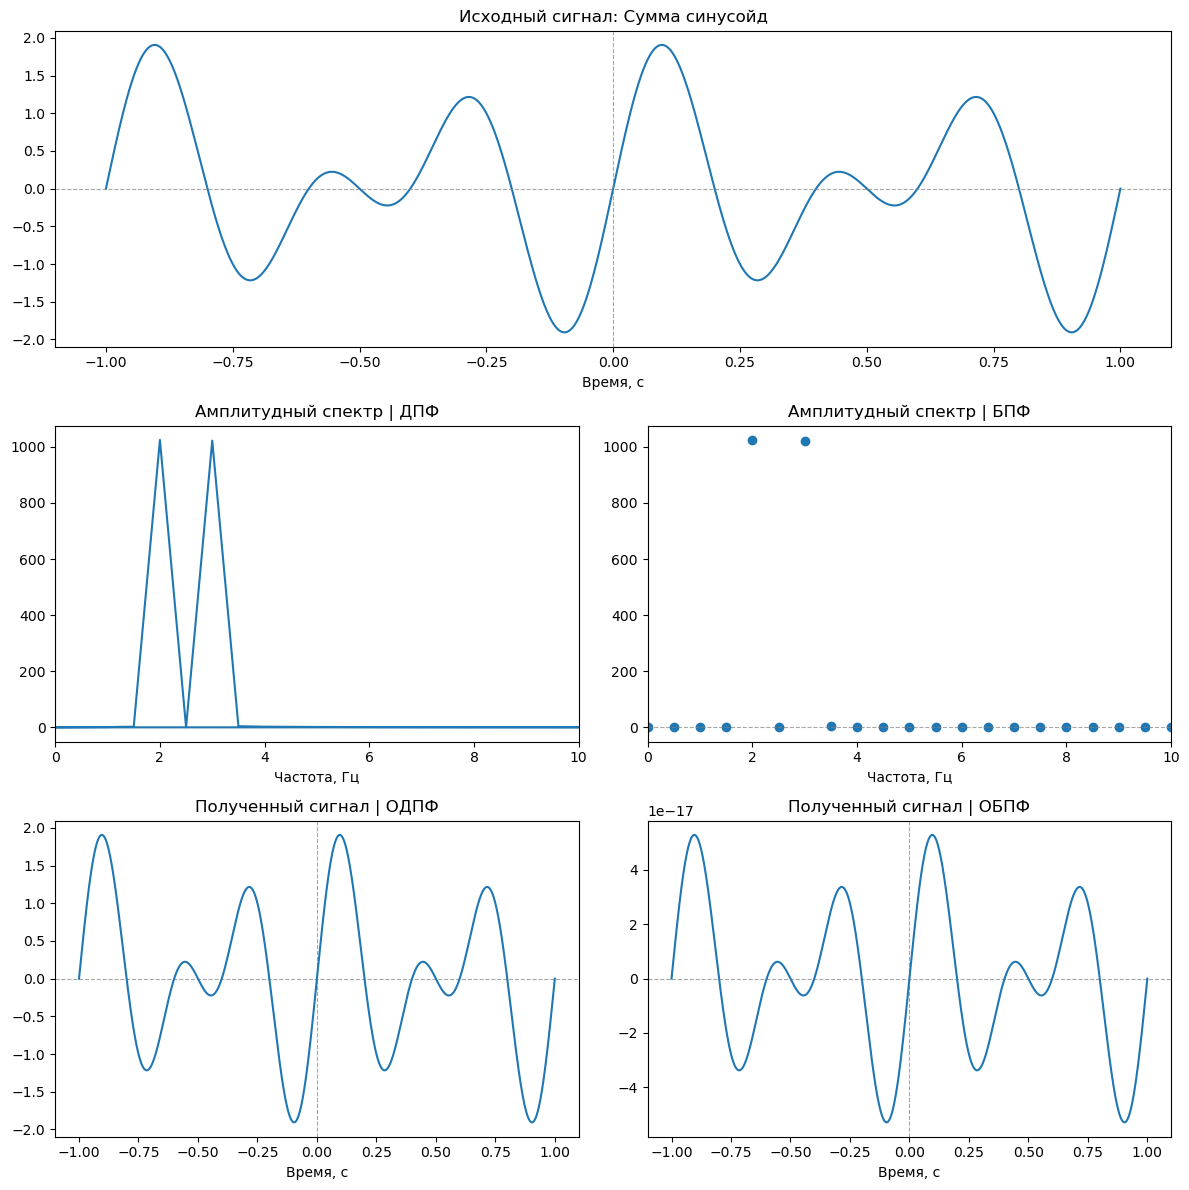

In [79]:
AnalaizerSignal(sumSinSignal, 'Сумма синусойд', N=2048, f_max=10)

Тестирование преобразования Фурье для Единичный импульс
Количество отсчётов: 1024, 1024
Временной интервал: [-1, 1]
Время ДПФ: 0.44842 с
Время БПФ: 0.00623 с
(1024, 1024)
Время ОДПФ: 0.36345 с
Время ОБПФ: 0.0048 с


/usr/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


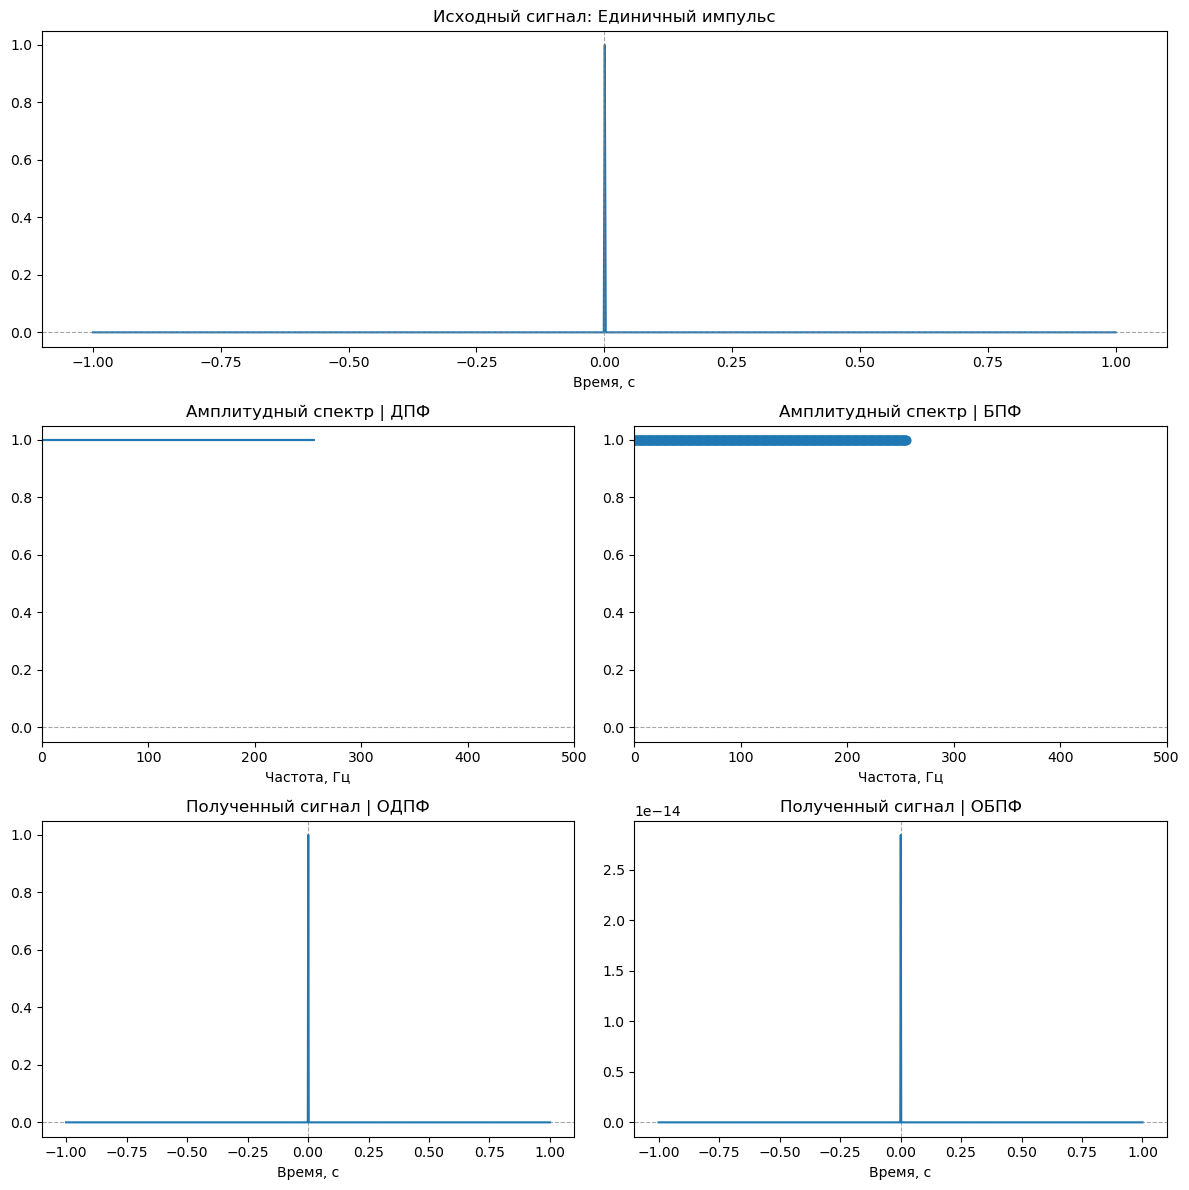

In [89]:
AnalaizerSignal(FImpulse, 'Единичный импульс')

Тестирование преобразования Фурье для Постоянный сигнал
Количество отсчётов: 2048, 2048
Временной интервал: [-1, 1]
Время ДПФ: 1.63088 с
Время БПФ: 0.01268 с
(2048, 2048)
Время ОДПФ: 1.37066 с
Время ОБПФ: 0.00872 с


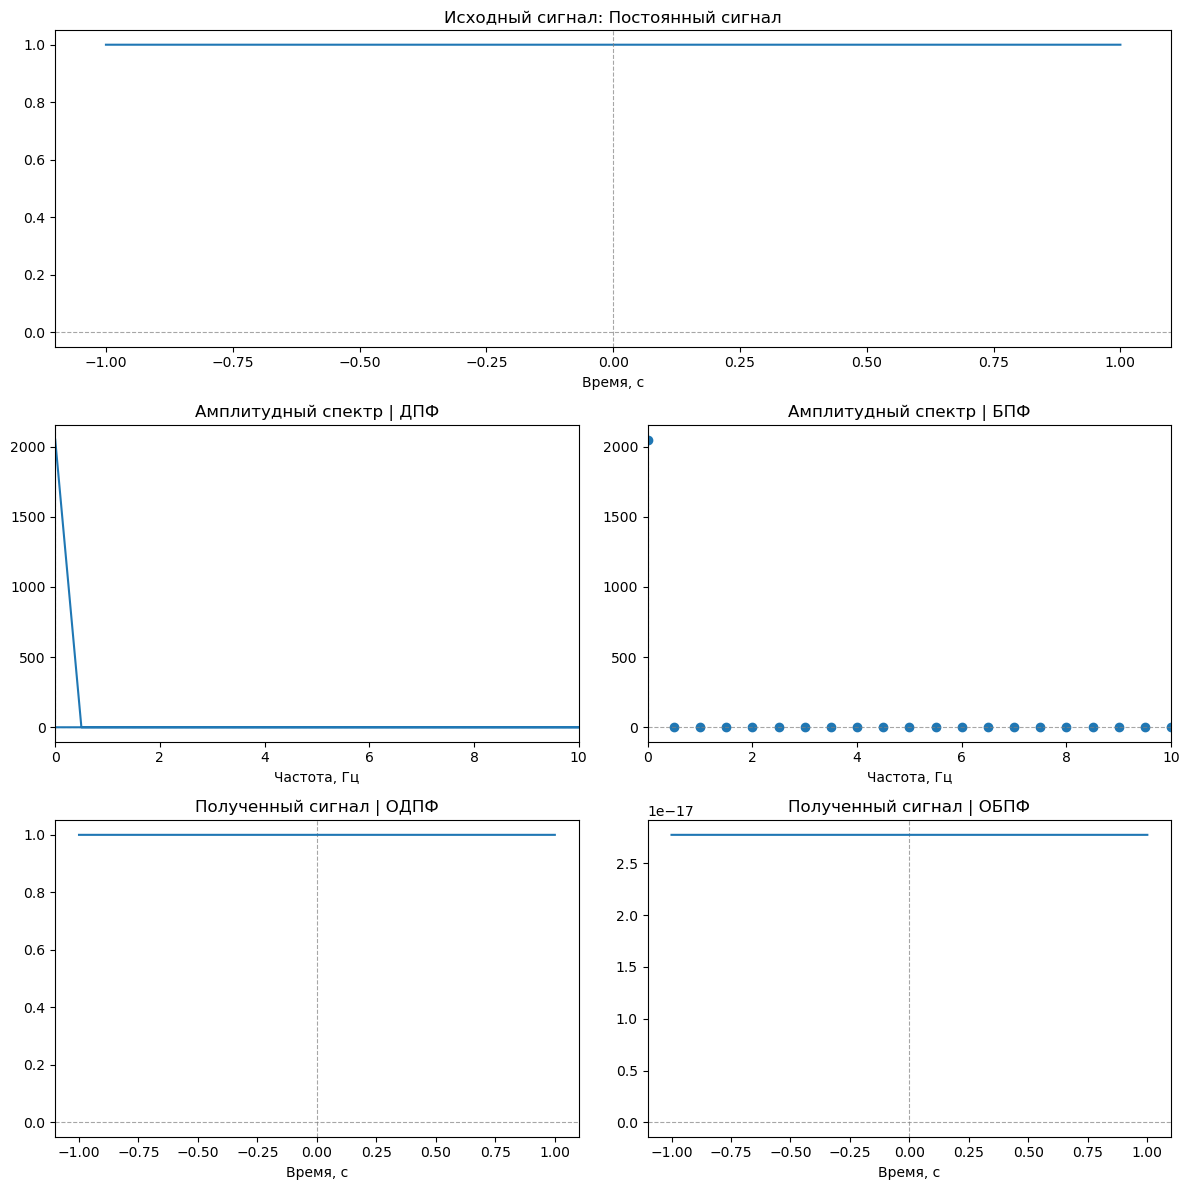

In [81]:
AnalaizerSignal(FConstSignal, 'Постоянный сигнал', N=2048, f_max=10)

Тестирование преобразования Фурье для Зашумлённый синус
Количество отсчётов: 1024, 1024
Временной интервал: [-1, 1]
Время ДПФ: 0.42751 с
Время БПФ: 0.00612 с
(1024, 1024)
Время ОДПФ: 0.39527 с
Время ОБПФ: 0.00394 с


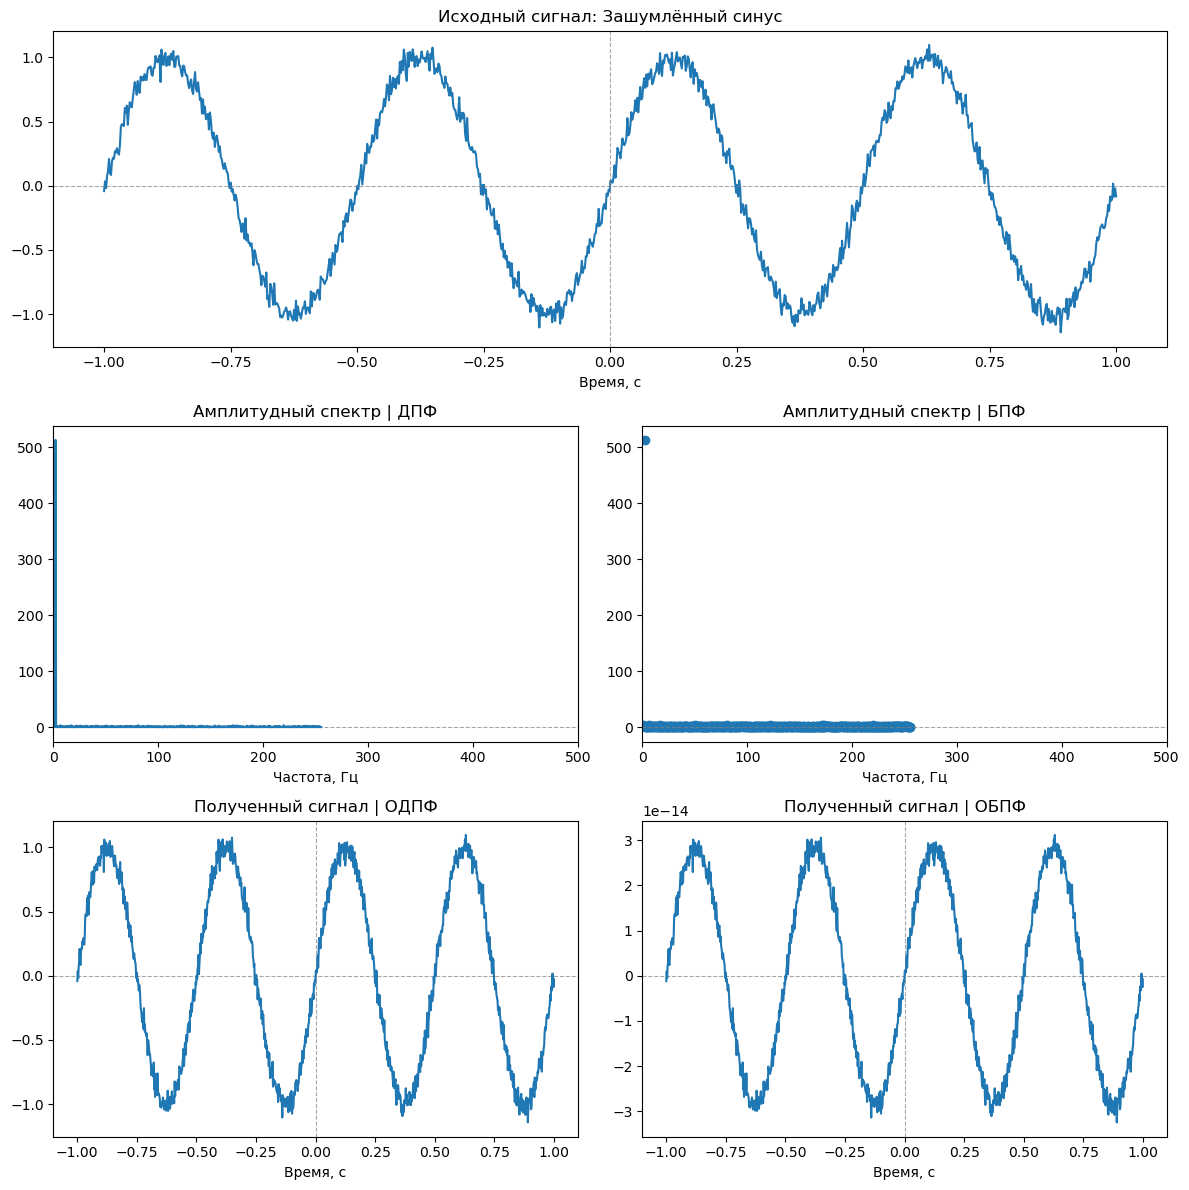

In [82]:
AnalaizerSignal(FNoisedSin, 'Зашумлённый синус')

Тестирование преобразования Фурье для Гаусс
Количество отсчётов: 2048, 2048
Временной интервал: [-1, 1]
Время ДПФ: 1.78572 с
Время БПФ: 0.01485 с
(2048, 2048)
Время ОДПФ: 1.3661 с
Время ОБПФ: 0.00947 с


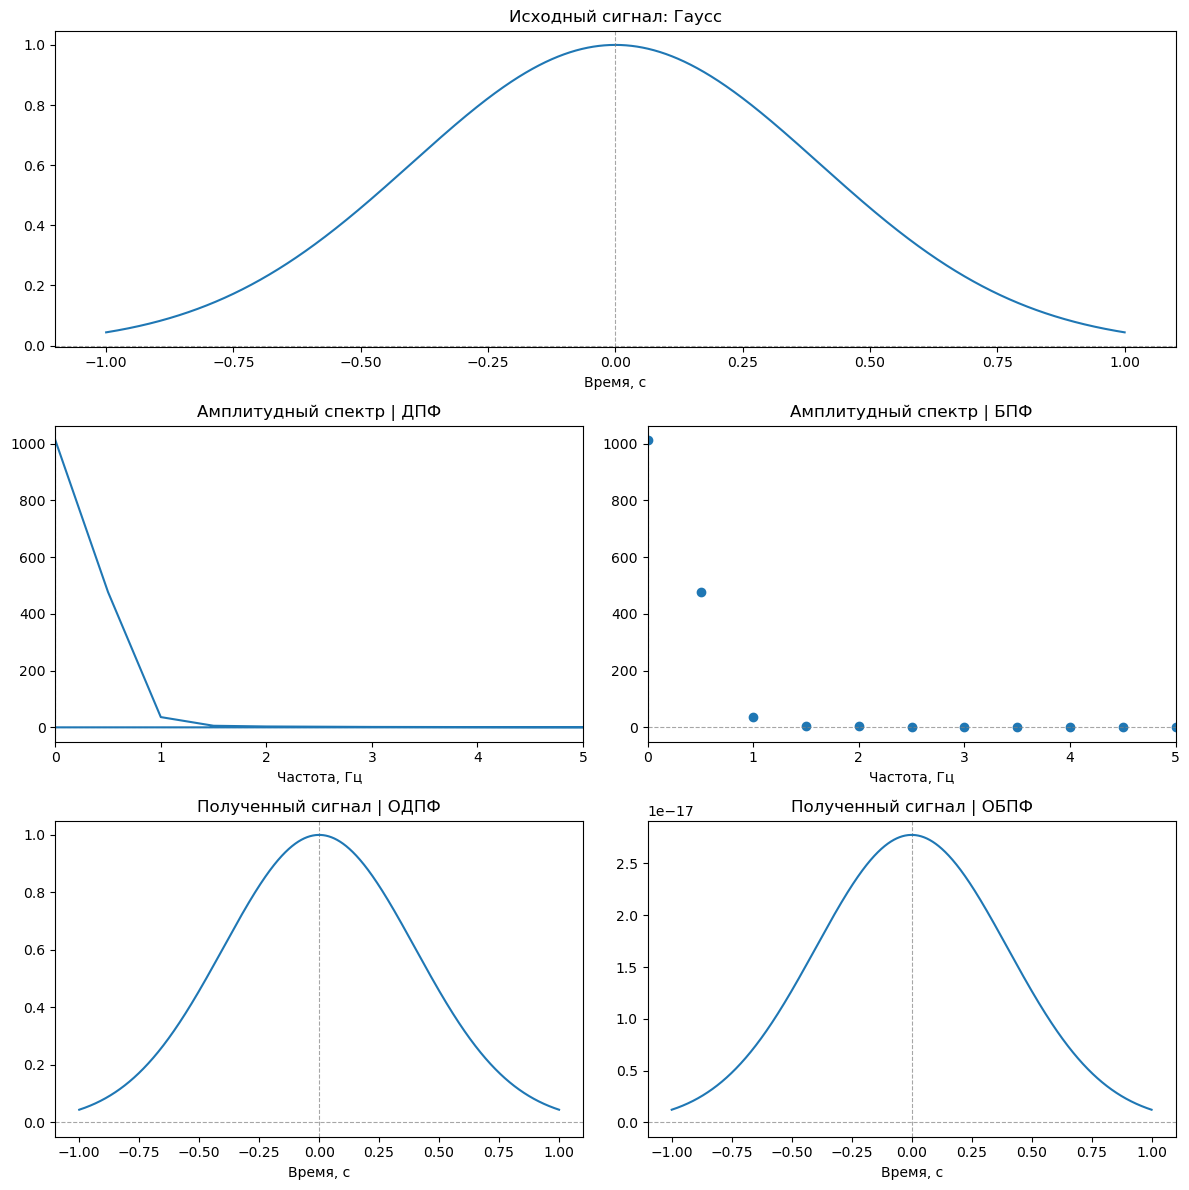

In [83]:
AnalaizerSignal(FGausse, 'Гаусс', N=2048, f_max=5)

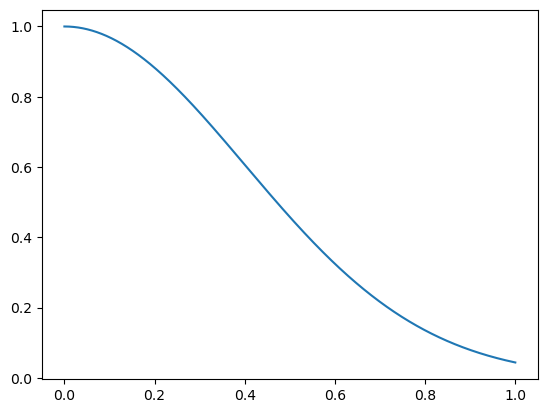

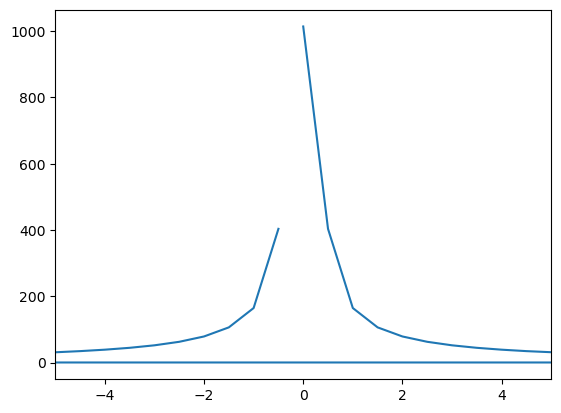

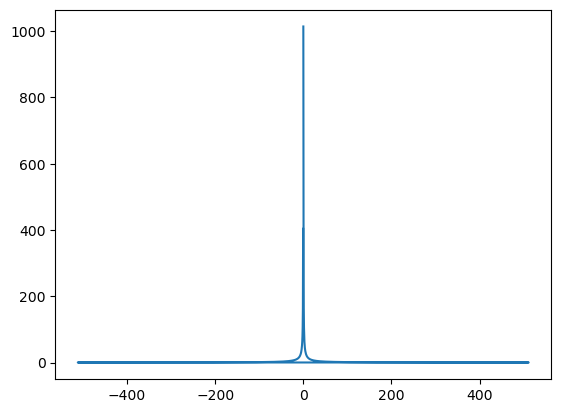

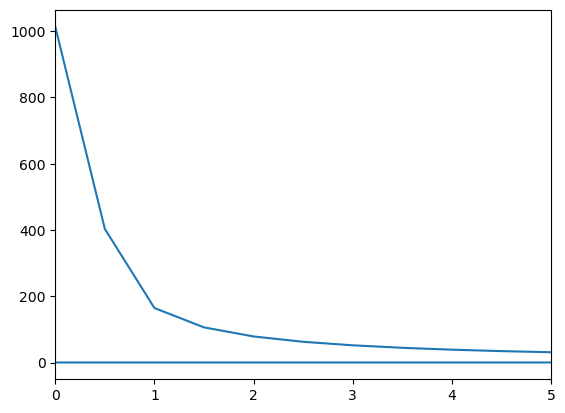

(2048, 2048)

In [84]:
N = 2048
t = np.linspace(0, 1, 2048)

signal = [FGausse(time) for time in t]


dft = DFT(signal)
fft = FFT(signal)
dft_ = np.fft.fft(signal)

ampl = [np.abs(el) for el in dft]
ampl_F = [np.abs(el) for el in fft]

w= np.fft.fftfreq(N, 2 / N)

plt.plot(t, signal)
plt.show()

plt.plot(w, ampl)
plt.xlim(-5, 5)
plt.show()
plt.plot(w, ampl_F)
# plt.xlim(-5, 5)
plt.show()

plt.xlim(0, 5)
ampl_ = [np.abs(el) for el in dft_]
plt.plot(w, ampl_)

# plt.xlim(-5, 5)
plt.show()
# plt.legend(['dft', 'np fft'])
len(dft), len(dft_)

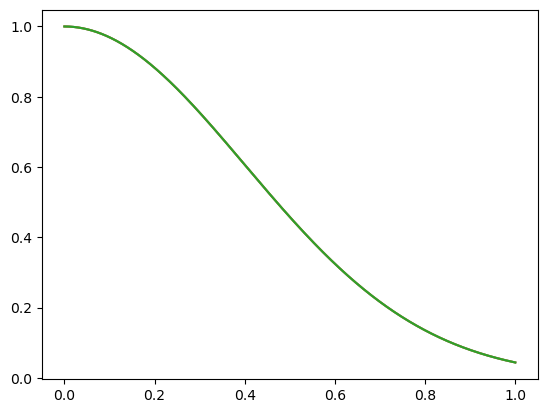

In [85]:
sig = IDFT(dft)
plt.plot(t, sig)
# plt.show()
sig = IDFT(dft_)

plt.plot(t, sig)

sig_f = IDFT(fft)

plt.plot(t, sig_f)

# plt.show()

In [86]:
# Тестовый пример
data = [1, 2, 3, 4]
result = DFT(data)
print("Мой DFT:", result)
print("NumPy DFT:", np.fft.fft(data))

Мой DFT: [10.+0.00000000e+00j -2.+2.00000000e+00j -2.-9.79717439e-16j
 -2.-2.00000000e+00j]
NumPy DFT: [10.+0.j -2.+2.j -2.+0.j -2.-2.j]


In [87]:
data = [1, 2, 3, 4]
fft_result = FFT(data)
numpy_result = np.fft.fft(data)
print("Мой FFT:", fft_result)
print("NumPy FFT:", numpy_result)
print("Совпадают?", np.allclose(fft_result, numpy_result))

Мой FFT: [10.+0.00000000e+00j -2.+2.00000000e+00j -2.-9.79717439e-16j
 -2.-2.00000000e+00j]
NumPy FFT: [10.+0.j -2.+2.j -2.+0.j -2.-2.j]
Совпадают? True
